# ECG Classification “ Eksperimen Skema Preprocessing

Notebook ini melatih model klasifikasi ECG dengan **3 skema preprocessing** dan **2 task klasifikasi**, sehingga total terdapat **6 kombinasi eksperimen**.

| Skema | Input | Task |
|---|---|---|
| Skema 1 | Gambar clean (1 gambar/sampel) | 2-class & 4-class |
| Skema 2 | 12 short lead + 1 long lead | 2-class & 4-class |
| Skema 3 | 6 lead tungkai + 6 lead precordial + long lead | 2-class & 4-class |

Semua eksperimen di-tracking menggunakan **MLflow via DagsHub**.

## 1. Import & Konfigurasi

In [1]:
import torch
from utils.config import Config
from utils.modeling import (
    init_dagshub,
    CLASS_NAMES_2, CLASS_NAMES_4,
    SCHEME_NAMES,
)

c:\Users\abiyamf\Documents\Code Program\TelUxMMU-Research-CardiacData\.venv\Lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## GPU Check

In [2]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU tidak tersedia, menggunakan CPU")

GPU: NVIDIA GeForce RTX 5070 Ti
Memory: 17.1 GB


In [3]:
# ── Hyperparameter ──────────────────────────────────────────────
NUM_EPOCHS    = 5
BATCH_SIZE    = 16
LEARNING_RATE = 1e-4
IMAGE_SIZE    = 224
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
OUTPUT_DIR    = "outputs/experiments"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Inisialisasi DagsHub & MLflow

In [4]:
init_dagshub(
    repo_owner=Config.dagshub_config["repo_owner"],
    repo_name=Config.dagshub_config["repo_name"],
)

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/TelUxMMU-Research"

Repository abiyamf/TelUxMMU-Research initialized!

DagsHub initialized: https://dagshub.com/abiyamf/TelUxMMU-Research


In [5]:
from utils.modeling import (
    _get_image_files_scheme1,
    ECGDatasetScheme1,
    build_dataloaders,
    build_model,
    train_model,
    evaluate_and_log,
)

records_s1 = _get_image_files_scheme1(Config.data_root)

dataset_s1_4c = ECGDatasetScheme1(records_s1, task="4class", image_size=IMAGE_SIZE)
train_s1_4c, val_s1_4c, test_s1_4c = build_dataloaders(
    dataset_s1_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_s1_4c, history_s1_4c, run_output_dir_s1_4c, run_id_s1_4c = train_model(
    model_s1_4c, train_s1_4c, val_s1_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_4class",
    scheme="scheme1", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme1_4class] Epoch 1/5 | Train Loss: 0.5261 Acc: 0.8071 | Val Loss: 0.3618 Acc: 0.9000
[scheme1_4class] Epoch 2/5 | Train Loss: 0.1372 Acc: 0.9599 | Val Loss: 0.0724 Acc: 0.9786
[scheme1_4class] Epoch 3/5 | Train Loss: 0.0485 Acc: 0.9892 | Val Loss: 0.0633 Acc: 0.9857
[scheme1_4class] Epoch 4/5 | Train Loss: 0.0206 Acc: 0.9969 | Val Loss: 0.0419 Acc: 0.9857


2026/04/21 22:24:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_4class] Epoch 5/5 | Train Loss: 0.0163 Acc: 0.9985 | Val Loss: 0.0735 Acc: 0.9714


2026/04/21 22:24:21 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\abiyamf\AppData\Local\Temp\tmpnq3deq7m\model\data, flavor: pytorch), fall back to return ['torch==2.11.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.
2026/04/21 22:24:21 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_4class_20260421_222118\best_model.pth
Training history saved to: outputs/experiments\scheme1_4class_20260421_222118\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_4class_20260421_222118\confusion_matrix_val.png


In [6]:
result_s1_4c = evaluate_and_log(
    model_s1_4c, test_s1_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme1", task="4class",
    run_name="scheme1_4class",
    output_dir=run_output_dir_s1_4c,
    parent_run_id=run_id_s1_4c,
)


=== Test Results | scheme1 | 4class ===
Accuracy : 0.9714
Macro F1 : 0.9695
ROC-AUC  : 0.9967
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.97        43
    Abnormal       1.00      0.94      0.97        35
          MI       1.00      1.00      1.00        36
  History MI       0.96      0.92      0.94        26

    accuracy                           0.97       140
   macro avg       0.97      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140

Test confusion matrix saved to: outputs/experiments\scheme1_4class_20260421_222118\confusion_matrix_test.png


In [7]:
dataset_s1_2c = ECGDatasetScheme1(records_s1, task="2class", image_size=IMAGE_SIZE)
train_s1_2c, val_s1_2c, test_s1_2c = build_dataloaders(
    dataset_s1_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_s1_2c, history_s1_2c, run_output_dir_s1_2c, run_id_s1_2c = train_model(
    model_s1_2c, train_s1_2c, val_s1_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_2class",
    scheme="scheme1", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme1_2class] Epoch 1/5 | Train Loss: 0.2283 Acc: 0.9105 | Val Loss: 0.3088 Acc: 0.8643
[scheme1_2class] Epoch 2/5 | Train Loss: 0.0581 Acc: 0.9784 | Val Loss: 0.1494 Acc: 0.9429
[scheme1_2class] Epoch 3/5 | Train Loss: 0.0181 Acc: 0.9969 | Val Loss: 0.0531 Acc: 0.9929
[scheme1_2class] Epoch 4/5 | Train Loss: 0.0337 Acc: 0.9907 | Val Loss: 0.1331 Acc: 0.9357


2026/04/21 22:28:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_2class] Epoch 5/5 | Train Loss: 0.0283 Acc: 0.9907 | Val Loss: 0.0946 Acc: 0.9786


2026/04/21 22:28:40 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 22:28:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_2class_20260421_222539\best_model.pth
Training history saved to: outputs/experiments\scheme1_2class_20260421_222539\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_2class_20260421_222539\confusion_matrix_val.png


In [8]:
result_s1_2c = evaluate_and_log(
    model_s1_2c, test_s1_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme1", task="2class",
    run_name="scheme1_2class",
    output_dir=run_output_dir_s1_2c,
    parent_run_id=run_id_s1_2c,
)


=== Test Results | scheme1 | 2class ===
Accuracy : 0.9929
Macro F1 : 0.9917
ROC-AUC  : 0.9995
              precision    recall  f1-score   support

       Sehat       0.98      1.00      0.99        43
       Sakit       1.00      0.99      0.99        97

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme1_2class_20260421_222539\confusion_matrix_test.png


In [9]:
from utils.modeling import _get_image_files_scheme2, ECGDatasetScheme2

records_s2 = _get_image_files_scheme2(Config.data_root)

dataset_s2_4c = ECGDatasetScheme2(records_s2, task="4class", image_size=IMAGE_SIZE)
train_s2_4c, val_s2_4c, test_s2_4c = build_dataloaders(
    dataset_s2_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# 13 leads x 3 channels = 39 input channels
model_s2_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s2_4c, history_s2_4c, run_output_dir_s2_4c, run_id_s2_4c = train_model(
    model_s2_4c, train_s2_4c, val_s2_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_4class",
    scheme="scheme2", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme2_4class] Epoch 1/5 | Train Loss: 0.6366 Acc: 0.7500 | Val Loss: 0.7736 Acc: 0.7143
[scheme2_4class] Epoch 2/5 | Train Loss: 0.1054 Acc: 0.9722 | Val Loss: 0.7223 Acc: 0.6214
[scheme2_4class] Epoch 3/5 | Train Loss: 0.0321 Acc: 0.9954 | Val Loss: 0.1979 Acc: 0.9286
[scheme2_4class] Epoch 4/5 | Train Loss: 0.0434 Acc: 0.9877 | Val Loss: 0.5128 Acc: 0.7500


2026/04/21 22:34:33 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_4class] Epoch 5/5 | Train Loss: 0.0639 Acc: 0.9799 | Val Loss: 0.5102 Acc: 0.8000


2026/04/21 22:34:38 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 22:34:38 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_4class_20260421_223015\best_model.pth
Training history saved to: outputs/experiments\scheme2_4class_20260421_223015\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_4class_20260421_223015\confusion_matrix_val.png


In [10]:
result_s2_4c = evaluate_and_log(
    model_s2_4c, test_s2_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme2", task="4class",
    run_name="scheme2_4class",
    output_dir=run_output_dir_s2_4c,
    parent_run_id=run_id_s2_4c,
)


=== Test Results | scheme2 | 4class ===
Accuracy : 0.9571
Macro F1 : 0.9543
ROC-AUC  : 0.9990
              precision    recall  f1-score   support

      Normal       0.95      0.98      0.97        43
    Abnormal       1.00      0.86      0.92        35
          MI       1.00      1.00      1.00        36
  History MI       0.87      1.00      0.93        26

    accuracy                           0.96       140
   macro avg       0.96      0.96      0.95       140
weighted avg       0.96      0.96      0.96       140

Test confusion matrix saved to: outputs/experiments\scheme2_4class_20260421_223015\confusion_matrix_test.png


In [11]:
dataset_s2_2c = ECGDatasetScheme2(records_s2, task="2class", image_size=IMAGE_SIZE)
train_s2_2c, val_s2_2c, test_s2_2c = build_dataloaders(
    dataset_s2_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s2_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s2_2c, history_s2_2c, run_output_dir_s2_2c, run_id_s2_2c = train_model(
    model_s2_2c, train_s2_2c, val_s2_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_2class",
    scheme="scheme2", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme2_2class] Epoch 1/5 | Train Loss: 0.2501 Acc: 0.8904 | Val Loss: 0.3730 Acc: 0.7929
[scheme2_2class] Epoch 2/5 | Train Loss: 0.0633 Acc: 0.9815 | Val Loss: 0.1747 Acc: 0.9429
[scheme2_2class] Epoch 3/5 | Train Loss: 0.0443 Acc: 0.9830 | Val Loss: 0.9693 Acc: 0.7214
[scheme2_2class] Epoch 4/5 | Train Loss: 0.0447 Acc: 0.9907 | Val Loss: 0.1615 Acc: 0.8929


2026/04/21 22:40:21 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_2class] Epoch 5/5 | Train Loss: 0.0159 Acc: 0.9954 | Val Loss: 0.1658 Acc: 0.9143


2026/04/21 22:40:26 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 22:40:26 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_2class_20260421_223613\best_model.pth
Training history saved to: outputs/experiments\scheme2_2class_20260421_223613\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_2class_20260421_223613\confusion_matrix_val.png


In [12]:
result_s2_2c = evaluate_and_log(
    model_s2_2c, test_s2_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme2", task="2class",
    run_name="scheme2_2class",
    output_dir=run_output_dir_s2_2c,
    parent_run_id=run_id_s2_2c,
)


=== Test Results | scheme2 | 2class ===
Accuracy : 0.9214
Macro F1 : 0.9083
ROC-AUC  : 0.9827
              precision    recall  f1-score   support

       Sehat       0.86      0.88      0.87        43
       Sakit       0.95      0.94      0.94        97

    accuracy                           0.92       140
   macro avg       0.91      0.91      0.91       140
weighted avg       0.92      0.92      0.92       140

Test confusion matrix saved to: outputs/experiments\scheme2_2class_20260421_223613\confusion_matrix_test.png


In [13]:
from utils.modeling import (
    _get_image_files_scheme3,
    ECGDatasetScheme3,
    build_model_multibranch,
    MultiBranchResNet18,
)

records_s3 = _get_image_files_scheme3(Config.data_root)

dataset_s3_4c = ECGDatasetScheme3(records_s3, task="4class", image_size=IMAGE_SIZE)
train_s3_4c, val_s3_4c, test_s3_4c = build_dataloaders(
    dataset_s3_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# Multi-branch: limb (18ch) + precordial (18ch) + long lead (3ch)
model_s3_4c = build_model_multibranch(num_classes=4).to(DEVICE)

model_s3_4c, history_s3_4c, run_output_dir_s3_4c, run_id_s3_4c = train_model(
    model_s3_4c, train_s3_4c, val_s3_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_4class",
    scheme="scheme3", task="4class",
    model_name="ResNet-18 MultiBranch", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme3_4class] Epoch 1/5 | Train Loss: 0.4372 Acc: 0.8164 | Val Loss: 0.1995 Acc: 0.9714
[scheme3_4class] Epoch 2/5 | Train Loss: 0.0542 Acc: 0.9846 | Val Loss: 0.2502 Acc: 0.9214
[scheme3_4class] Epoch 3/5 | Train Loss: 0.0256 Acc: 0.9954 | Val Loss: 0.1137 Acc: 0.9571
[scheme3_4class] Epoch 4/5 | Train Loss: 0.0168 Acc: 0.9969 | Val Loss: 0.1122 Acc: 0.9714


2026/04/21 22:45:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_4class] Epoch 5/5 | Train Loss: 0.0086 Acc: 0.9985 | Val Loss: 0.0740 Acc: 0.9714


2026/04/21 22:46:03 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 22:46:03 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_4class_20260421_224203\best_model.pth
Training history saved to: outputs/experiments\scheme3_4class_20260421_224203\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_4class_20260421_224203\confusion_matrix_val.png


In [14]:
result_s3_4c = evaluate_and_log(
    model_s3_4c, test_s3_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme3", task="4class",
    run_name="scheme3_4class",
    output_dir=run_output_dir_s3_4c,
    parent_run_id=run_id_s3_4c,
)


=== Test Results | scheme3 | 4class ===
Accuracy : 0.9500
Macro F1 : 0.9456
ROC-AUC  : 0.9946
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.98        43
    Abnormal       0.91      0.91      0.91        35
          MI       0.97      1.00      0.99        36
  History MI       0.89      0.92      0.91        26

    accuracy                           0.95       140
   macro avg       0.94      0.95      0.95       140
weighted avg       0.95      0.95      0.95       140

Test confusion matrix saved to: outputs/experiments\scheme3_4class_20260421_224203\confusion_matrix_test.png


In [15]:
dataset_s3_2c = ECGDatasetScheme3(records_s3, task="2class", image_size=IMAGE_SIZE)
train_s3_2c, val_s3_2c, test_s3_2c = build_dataloaders(
    dataset_s3_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_2c = build_model_multibranch(num_classes=2).to(DEVICE)

model_s3_2c, history_s3_2c, run_output_dir_s3_2c, run_id_s3_2c = train_model(
    model_s3_2c, train_s3_2c, val_s3_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_2class",
    scheme="scheme3", task="2class",
    model_name="ResNet-18 MultiBranch", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme3_2class] Epoch 1/5 | Train Loss: 0.2311 Acc: 0.8873 | Val Loss: 0.3137 Acc: 0.8357
[scheme3_2class] Epoch 2/5 | Train Loss: 0.0409 Acc: 0.9846 | Val Loss: 0.2738 Acc: 0.8643
[scheme3_2class] Epoch 3/5 | Train Loss: 0.0095 Acc: 0.9985 | Val Loss: 0.0578 Acc: 0.9857
[scheme3_2class] Epoch 4/5 | Train Loss: 0.0082 Acc: 0.9969 | Val Loss: 0.5409 Acc: 0.8143


2026/04/21 22:52:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_2class] Epoch 5/5 | Train Loss: 0.0100 Acc: 0.9985 | Val Loss: 0.1150 Acc: 0.9429


2026/04/21 22:52:09 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 22:52:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_2class_20260421_224810\best_model.pth
Training history saved to: outputs/experiments\scheme3_2class_20260421_224810\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_2class_20260421_224810\confusion_matrix_val.png


## 4. Raw Data (Tanpa Preprocessing)

Section ini melatih model ResNet-18 menggunakan data mentah (raw) dari folder `data/raw/` tanpa preprocessing apapun.

In [16]:
from utils.modeling import _get_image_files_raw, ECGDatasetRaw

records_raw = _get_image_files_raw(Config.data_root)

dataset_raw_4c = ECGDatasetRaw(records_raw, task="4class", image_size=IMAGE_SIZE)
train_raw_4c, val_raw_4c, test_raw_4c = build_dataloaders(
    dataset_raw_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_raw_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_raw_4c, history_raw_4c, run_output_dir_raw_4c, run_id_raw_4c = train_model(
    model_raw_4c, train_raw_4c, val_raw_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="raw_4class",
    scheme="raw", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[raw_4class] Epoch 1/5 | Train Loss: 0.4998 Acc: 0.8241 | Val Loss: 0.3242 Acc: 0.9214
[raw_4class] Epoch 2/5 | Train Loss: 0.0809 Acc: 0.9784 | Val Loss: 0.0993 Acc: 0.9714
[raw_4class] Epoch 3/5 | Train Loss: 0.0247 Acc: 0.9969 | Val Loss: 0.0679 Acc: 0.9786
[raw_4class] Epoch 4/5 | Train Loss: 0.0308 Acc: 0.9938 | Val Loss: 0.0767 Acc: 0.9857


2026/04/21 22:55:35 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[raw_4class] Epoch 5/5 | Train Loss: 0.0378 Acc: 0.9892 | Val Loss: 0.1002 Acc: 0.9714


2026/04/21 22:55:39 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 22:55:39 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\raw_4class_20260421_225329\best_model.pth
Training history saved to: outputs/experiments\raw_4class_20260421_225329\training_history.png
Confusion matrix saved to: outputs/experiments\raw_4class_20260421_225329\confusion_matrix_val.png


In [17]:
result_raw_4c = evaluate_and_log(
    model_raw_4c, test_raw_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="raw", task="4class",
    run_name="raw_4class",
    output_dir=run_output_dir_raw_4c,
    parent_run_id=run_id_raw_4c,
)


=== Test Results | raw | 4class ===
Accuracy : 0.9786
Macro F1 : 0.9766
ROC-AUC  : 0.9988
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        43
    Abnormal       0.97      0.94      0.96        35
          MI       1.00      1.00      1.00        36
  History MI       0.96      0.96      0.96        26

    accuracy                           0.98       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140

Test confusion matrix saved to: outputs/experiments\raw_4class_20260421_225329\confusion_matrix_test.png


In [18]:
dataset_raw_2c = ECGDatasetRaw(records_raw, task="2class", image_size=IMAGE_SIZE)
train_raw_2c, val_raw_2c, test_raw_2c = build_dataloaders(
    dataset_raw_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_raw_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_raw_2c, history_raw_2c, run_output_dir_raw_2c, run_id_raw_2c = train_model(
    model_raw_2c, train_raw_2c, val_raw_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="raw_2class",
    scheme="raw", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[raw_2class] Epoch 1/5 | Train Loss: 0.2287 Acc: 0.9213 | Val Loss: 0.2020 Acc: 0.9000
[raw_2class] Epoch 2/5 | Train Loss: 0.0513 Acc: 0.9846 | Val Loss: 0.0667 Acc: 0.9786
[raw_2class] Epoch 3/5 | Train Loss: 0.0199 Acc: 0.9954 | Val Loss: 0.0837 Acc: 0.9786
[raw_2class] Epoch 4/5 | Train Loss: 0.0093 Acc: 0.9985 | Val Loss: 0.0510 Acc: 0.9714


2026/04/21 22:58:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[raw_2class] Epoch 5/5 | Train Loss: 0.0381 Acc: 0.9830 | Val Loss: 0.0610 Acc: 0.9714


2026/04/21 22:58:54 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 22:58:54 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\raw_2class_20260421_225640\best_model.pth
Training history saved to: outputs/experiments\raw_2class_20260421_225640\training_history.png
Confusion matrix saved to: outputs/experiments\raw_2class_20260421_225640\confusion_matrix_val.png


In [19]:
result_raw_2c = evaluate_and_log(
    model_raw_2c, test_raw_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="raw", task="2class",
    run_name="raw_2class",
    output_dir=run_output_dir_raw_2c,
    parent_run_id=run_id_raw_2c,
)


=== Test Results | raw | 2class ===
Accuracy : 0.9786
Macro F1 : 0.9753
ROC-AUC  : 0.9995
              precision    recall  f1-score   support

       Sehat       0.93      1.00      0.97        43
       Sakit       1.00      0.97      0.98        97

    accuracy                           0.98       140
   macro avg       0.97      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140

Test confusion matrix saved to: outputs/experiments\raw_2class_20260421_225640\confusion_matrix_test.png


## 5. Long Lead Only (Lead II – Preprocessed)

Section ini melatih model ResNet-18 menggunakan hanya long lead (13_long_lead.png) dari data yang sudah melalui preprocessing.

In [20]:
from utils.modeling import _get_image_files_longlead, ECGDatasetLongLead

records_ll = _get_image_files_longlead(Config.data_root)

dataset_ll_4c = ECGDatasetLongLead(records_ll, task="4class", image_size=IMAGE_SIZE)
train_ll_4c, val_ll_4c, test_ll_4c = build_dataloaders(
    dataset_ll_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_ll_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_ll_4c, history_ll_4c, run_output_dir_ll_4c, run_id_ll_4c = train_model(
    model_ll_4c, train_ll_4c, val_ll_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="longlead_4class",
    scheme="longlead", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[longlead_4class] Epoch 1/5 | Train Loss: 0.7535 Acc: 0.6991 | Val Loss: 0.7199 Acc: 0.7286
[longlead_4class] Epoch 2/5 | Train Loss: 0.1837 Acc: 0.9460 | Val Loss: 0.3450 Acc: 0.8929
[longlead_4class] Epoch 3/5 | Train Loss: 0.0744 Acc: 0.9861 | Val Loss: 0.3625 Acc: 0.8857
[longlead_4class] Epoch 4/5 | Train Loss: 0.0557 Acc: 0.9923 | Val Loss: 0.3726 Acc: 0.9071


2026/04/21 23:01:45 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[longlead_4class] Epoch 5/5 | Train Loss: 0.0241 Acc: 0.9954 | Val Loss: 0.4099 Acc: 0.8857


2026/04/21 23:01:49 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 23:01:49 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\longlead_4class_20260421_225934\best_model.pth
Training history saved to: outputs/experiments\longlead_4class_20260421_225934\training_history.png
Confusion matrix saved to: outputs/experiments\longlead_4class_20260421_225934\confusion_matrix_val.png


In [21]:
result_ll_4c = evaluate_and_log(
    model_ll_4c, test_ll_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="longlead", task="4class",
    run_name="longlead_4class",
    output_dir=run_output_dir_ll_4c,
    parent_run_id=run_id_ll_4c,
)


=== Test Results | longlead | 4class ===
Accuracy : 0.9286
Macro F1 : 0.9201
ROC-AUC  : 0.9861
              precision    recall  f1-score   support

      Normal       0.91      0.93      0.92        43
    Abnormal       0.92      0.97      0.94        35
          MI       1.00      1.00      1.00        36
  History MI       0.87      0.77      0.82        26

    accuracy                           0.93       140
   macro avg       0.92      0.92      0.92       140
weighted avg       0.93      0.93      0.93       140

Test confusion matrix saved to: outputs/experiments\longlead_4class_20260421_225934\confusion_matrix_test.png


In [22]:
dataset_ll_2c = ECGDatasetLongLead(records_ll, task="2class", image_size=IMAGE_SIZE)
train_ll_2c, val_ll_2c, test_ll_2c = build_dataloaders(
    dataset_ll_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_ll_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_ll_2c, history_ll_2c, run_output_dir_ll_2c, run_id_ll_2c = train_model(
    model_ll_2c, train_ll_2c, val_ll_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="longlead_2class",
    scheme="longlead", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[longlead_2class] Epoch 1/5 | Train Loss: 0.3952 Acc: 0.8287 | Val Loss: 0.3549 Acc: 0.8071
[longlead_2class] Epoch 2/5 | Train Loss: 0.1111 Acc: 0.9660 | Val Loss: 0.1597 Acc: 0.9500
[longlead_2class] Epoch 3/5 | Train Loss: 0.0440 Acc: 0.9892 | Val Loss: 0.1979 Acc: 0.9500
[longlead_2class] Epoch 4/5 | Train Loss: 0.0515 Acc: 0.9830 | Val Loss: 0.3661 Acc: 0.9000


2026/04/21 23:04:43 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[longlead_2class] Epoch 5/5 | Train Loss: 0.0470 Acc: 0.9846 | Val Loss: 0.1889 Acc: 0.9500


2026/04/21 23:04:48 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/21 23:04:48 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\longlead_2class_20260421_230231\best_model.pth
Training history saved to: outputs/experiments\longlead_2class_20260421_230231\training_history.png
Confusion matrix saved to: outputs/experiments\longlead_2class_20260421_230231\confusion_matrix_val.png


In [23]:
result_ll_2c = evaluate_and_log(
    model_ll_2c, test_ll_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="longlead", task="2class",
    run_name="longlead_2class",
    output_dir=run_output_dir_ll_2c,
    parent_run_id=run_id_ll_2c,
)


=== Test Results | longlead | 2class ===
Accuracy : 0.9286
Macro F1 : 0.9150
ROC-AUC  : 0.9729
              precision    recall  f1-score   support

       Sehat       0.90      0.86      0.88        43
       Sakit       0.94      0.96      0.95        97

    accuracy                           0.93       140
   macro avg       0.92      0.91      0.91       140
weighted avg       0.93      0.93      0.93       140

Test confusion matrix saved to: outputs/experiments\longlead_2class_20260421_230231\confusion_matrix_test.png


In [24]:
result_s3_2c = evaluate_and_log(
    model_s3_2c, test_s3_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme3", task="2class",
    run_name="scheme3_2class",
    output_dir=run_output_dir_s3_2c,
    parent_run_id=run_id_s3_2c,
)


=== Test Results | scheme3 | 2class ===
Accuracy : 0.9857
Macro F1 : 0.9832
ROC-AUC  : 0.9969
              precision    recall  f1-score   support

       Sehat       0.98      0.98      0.98        43
       Sakit       0.99      0.99      0.99        97

    accuracy                           0.99       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme3_2class_20260421_224810\confusion_matrix_test.png


=== Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch) ===
                 Scheme    Task  Accuracy  Macro F1  ROC-AUC
       Scheme 2 (Stack) 4-Class    0.9571    0.9543   0.9990
       Scheme 2 (Stack) 2-Class    0.9214    0.9083   0.9827
Scheme 3 (Multi-Branch) 4-Class    0.9500    0.9456   0.9946
Scheme 3 (Multi-Branch) 2-Class    0.9857    0.9832   0.9969


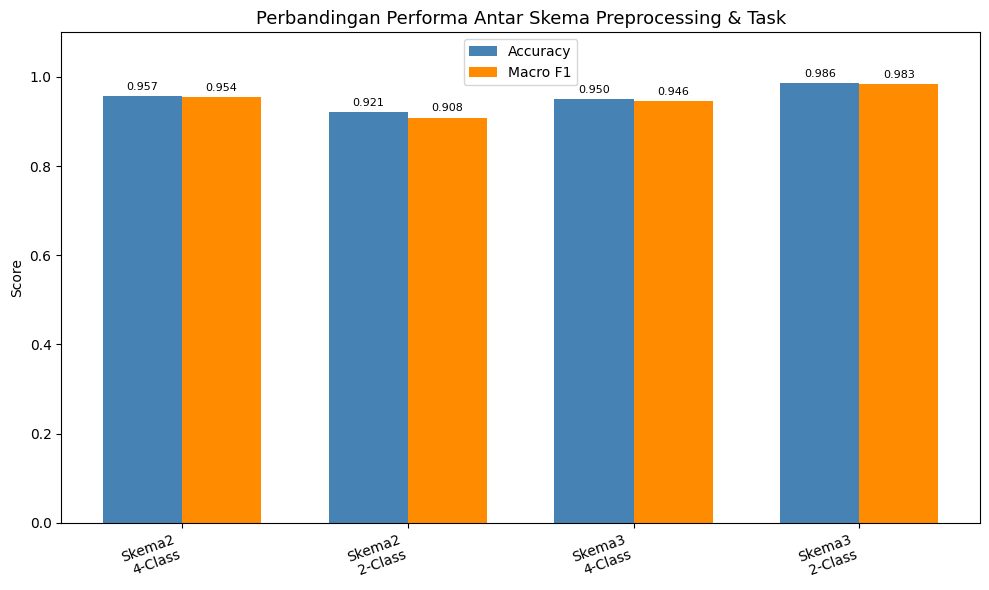

In [25]:
# Perbandingan Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch)
import pandas as pd

comparison_data = {
    "Scheme":   ["Scheme 2 (Stack)", "Scheme 2 (Stack)",
                 "Scheme 3 (Multi-Branch)", "Scheme 3 (Multi-Branch)"],
    "Task":     ["4-Class", "2-Class", "4-Class", "2-Class"],
    "Accuracy": [result_s2_4c["accuracy"], result_s2_2c["accuracy"],
                 result_s3_4c["accuracy"], result_s3_2c["accuracy"]],
    "Macro F1": [result_s2_4c["f1"],       result_s2_2c["f1"],
                 result_s3_4c["f1"],        result_s3_2c["f1"]],
    "ROC-AUC":  [result_s2_4c["roc_auc"],  result_s2_2c["roc_auc"],
                 result_s3_4c["roc_auc"],   result_s3_2c["roc_auc"]],
}

df_compare = pd.DataFrame(comparison_data)
print("=== Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch) ===")
print(df_compare.to_string(index=False, float_format="{:.4f}".format))

from utils.modeling import plot_scheme_comparison
plot_scheme_comparison({
    "Skema2\n4-Class": result_s2_4c,
    "Skema2\n2-Class": result_s2_2c,
    "Skema3\n4-Class": result_s3_4c,
    "Skema3\n2-Class": result_s3_2c,
})

## 6. Visualisasi Perbandingan Hasil

Bagian ini membandingkan performa semua skema dan task secara visual.

### 6.1 Training History – Task 4-Class

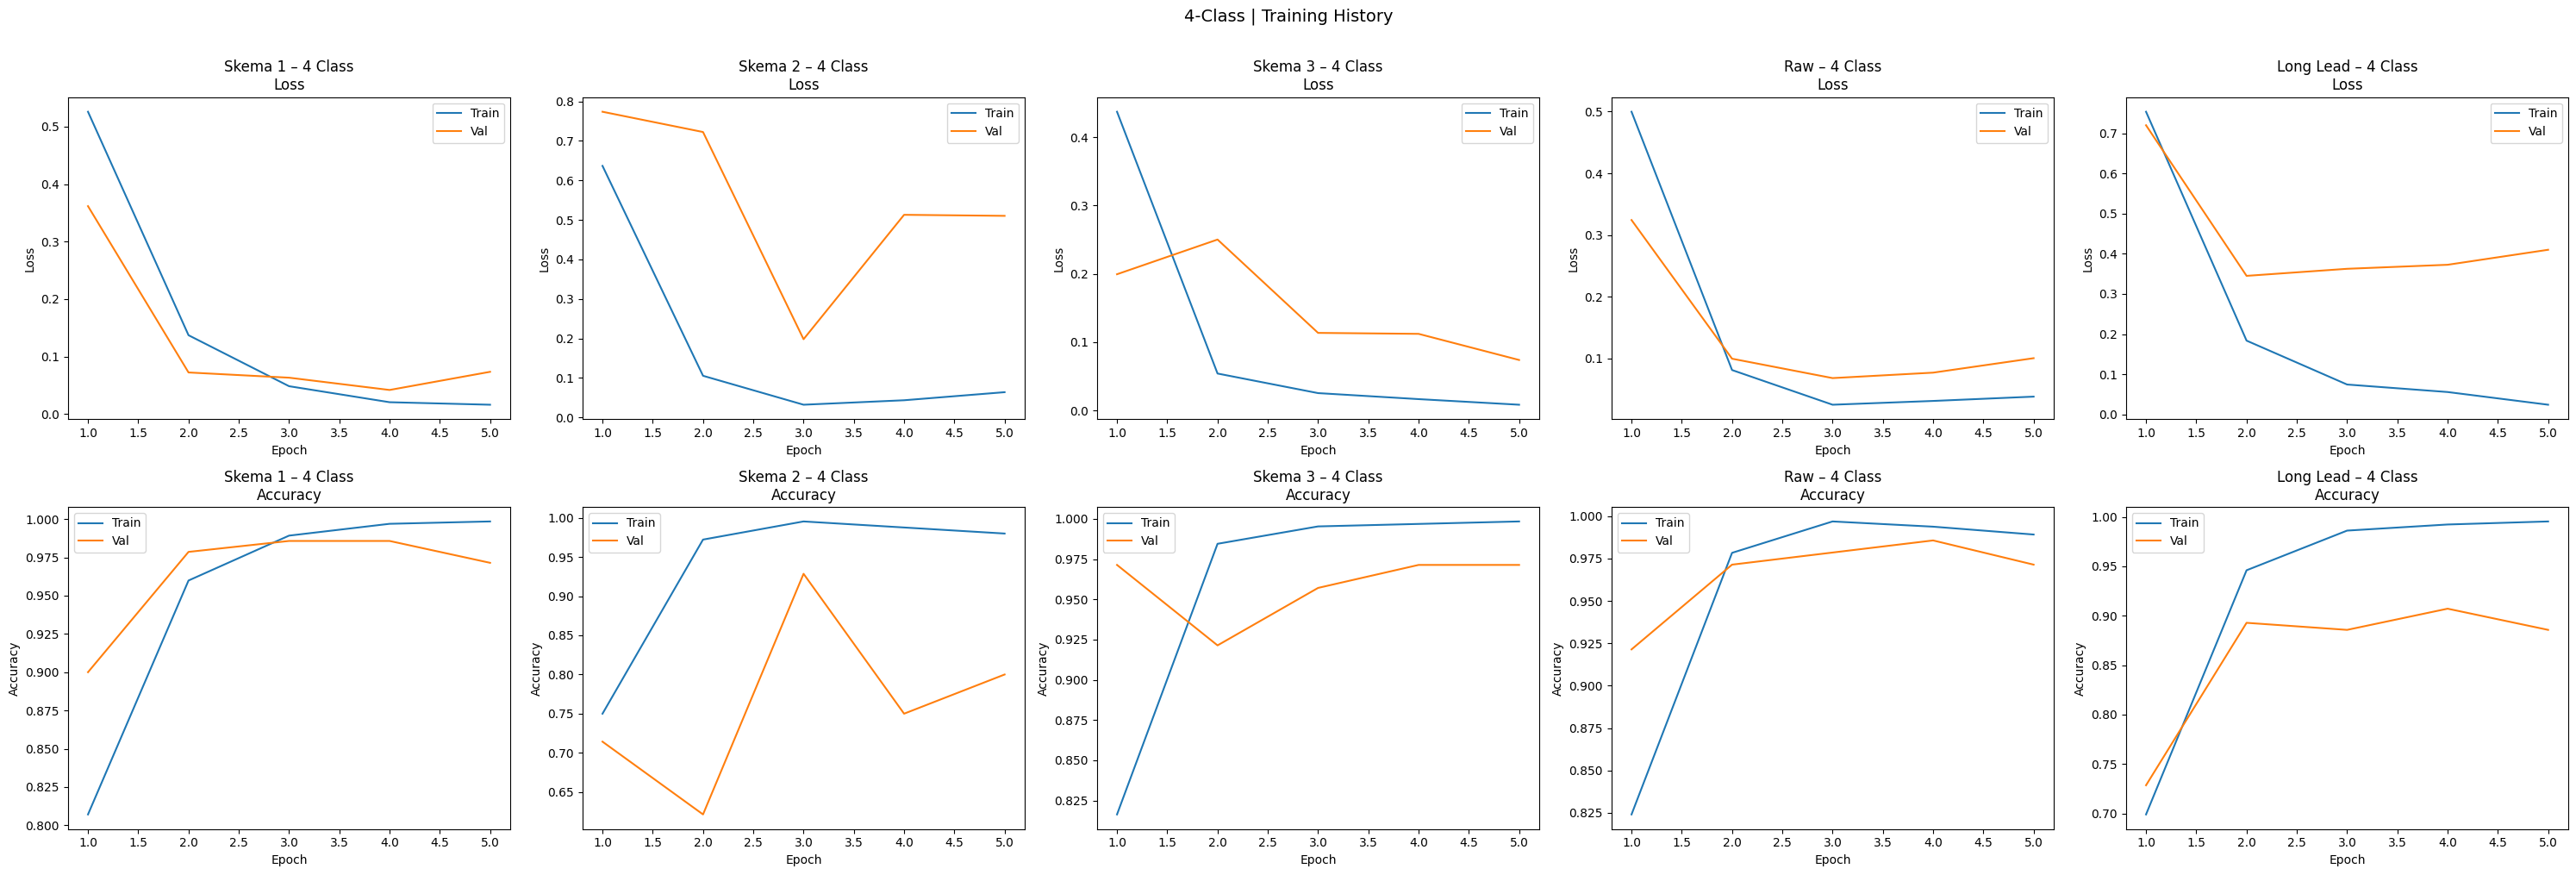

In [26]:
from utils.modeling import plot_training_history

plot_training_history(
    histories={
        "Skema 1 – 4 Class": history_s1_4c,
        "Skema 2 – 4 Class": history_s2_4c,
        "Skema 3 – 4 Class": history_s3_4c,
        "Raw – 4 Class": history_raw_4c,
        "Long Lead – 4 Class": history_ll_4c,
    },
    title_prefix="4-Class | "
)

### 6.2 Training History – Task 2-Class

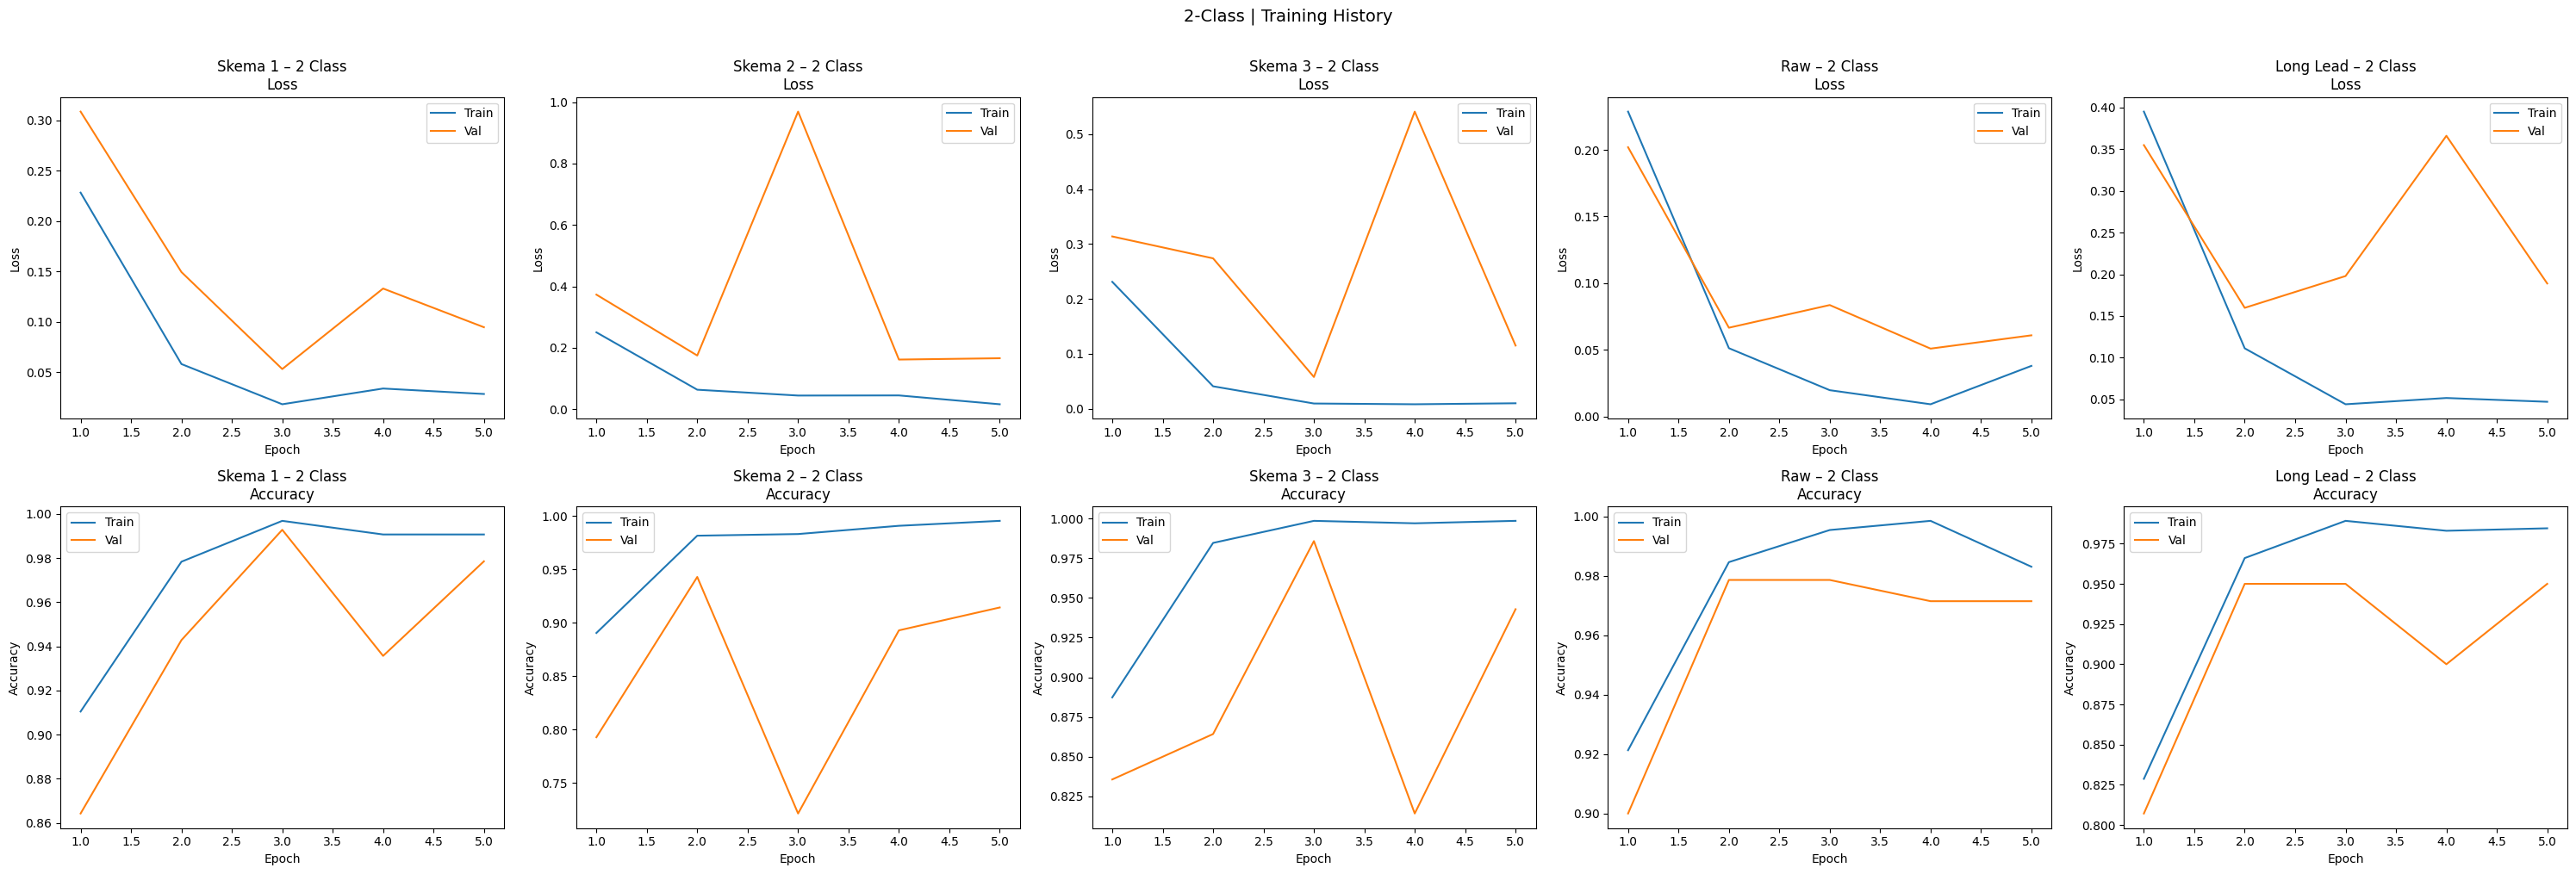

In [27]:
plot_training_history(
    histories={
        "Skema 1 – 2 Class": history_s1_2c,
        "Skema 2 – 2 Class": history_s2_2c,
        "Skema 3 – 2 Class": history_s3_2c,
        "Raw – 2 Class": history_raw_2c,
        "Long Lead – 2 Class": history_ll_2c,
    },
    title_prefix="2-Class | "
)

### 6.3 Confusion Matrix – Task 4-Class

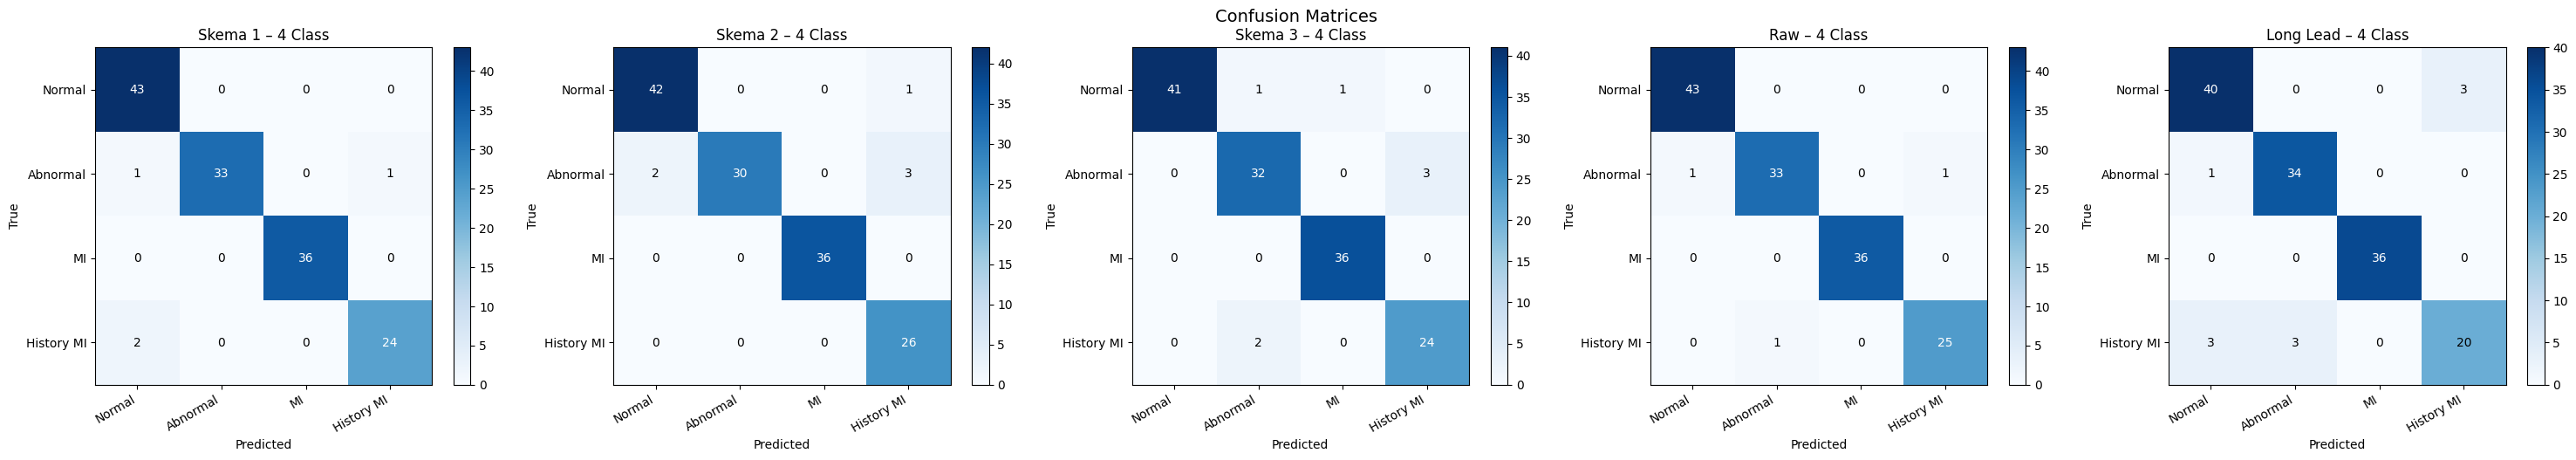

In [28]:
from utils.modeling import plot_confusion_matrices

plot_confusion_matrices(
    results={
        "Skema 1 – 4 Class": result_s1_4c,
        "Skema 2 – 4 Class": result_s2_4c,
        "Skema 3 – 4 Class": result_s3_4c,
        "Raw – 4 Class": result_raw_4c,
        "Long Lead – 4 Class": result_ll_4c,
    },
    class_names=CLASS_NAMES_4
)

### 6.4 Confusion Matrix – Task 2-Class

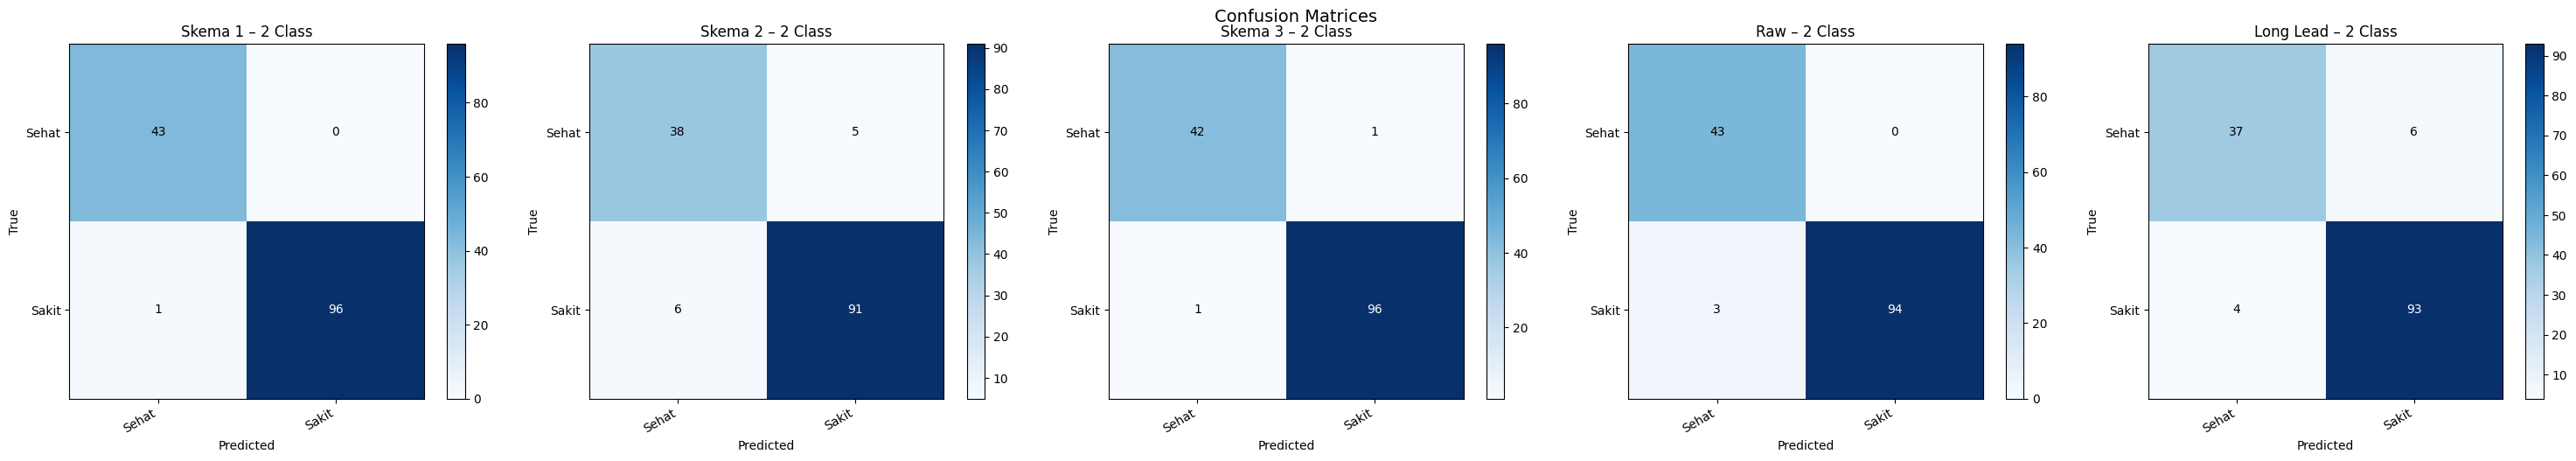

In [29]:
plot_confusion_matrices(
    results={
        "Skema 1 – 2 Class": result_s1_2c,
        "Skema 2 – 2 Class": result_s2_2c,
        "Skema 3 – 2 Class": result_s3_2c,
        "Raw – 2 Class": result_raw_2c,
        "Long Lead – 2 Class": result_ll_2c,
    },
    class_names=CLASS_NAMES_2
)

### 6.5 Perbandingan Akhir – Accuracy & Macro F1 Semua Skema

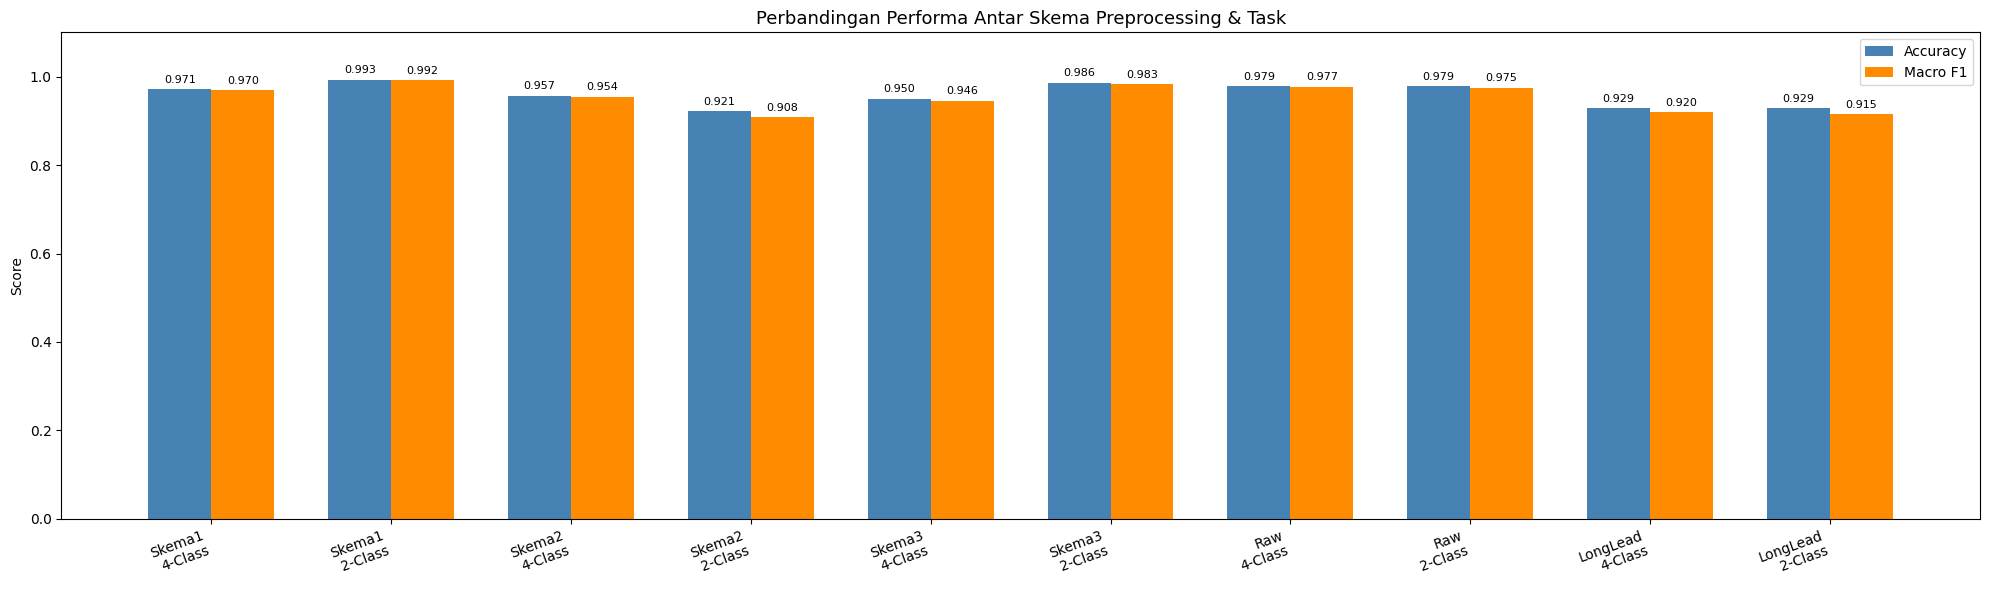

In [30]:
from utils.modeling import plot_scheme_comparison

all_results = {
    "Skema1\n4-Class": result_s1_4c,
    "Skema1\n2-Class": result_s1_2c,
    "Skema2\n4-Class": result_s2_4c,
    "Skema2\n2-Class": result_s2_2c,
    "Skema3\n4-Class": result_s3_4c,
    "Skema3\n2-Class": result_s3_2c,
    "Raw\n4-Class": result_raw_4c,
    "Raw\n2-Class": result_raw_2c,
    "LongLead\n4-Class": result_ll_4c,
    "LongLead\n2-Class": result_ll_2c,
}

plot_scheme_comparison(all_results)

### 6.6 Sample Predictions – Skema Terbaik

Visualisasi prediksi model pada sampel acak dari dataset test. Ganti variabel `best_model` dan `best_dataset` sesuai skema dengan performa terbaik dari grafik di atas.

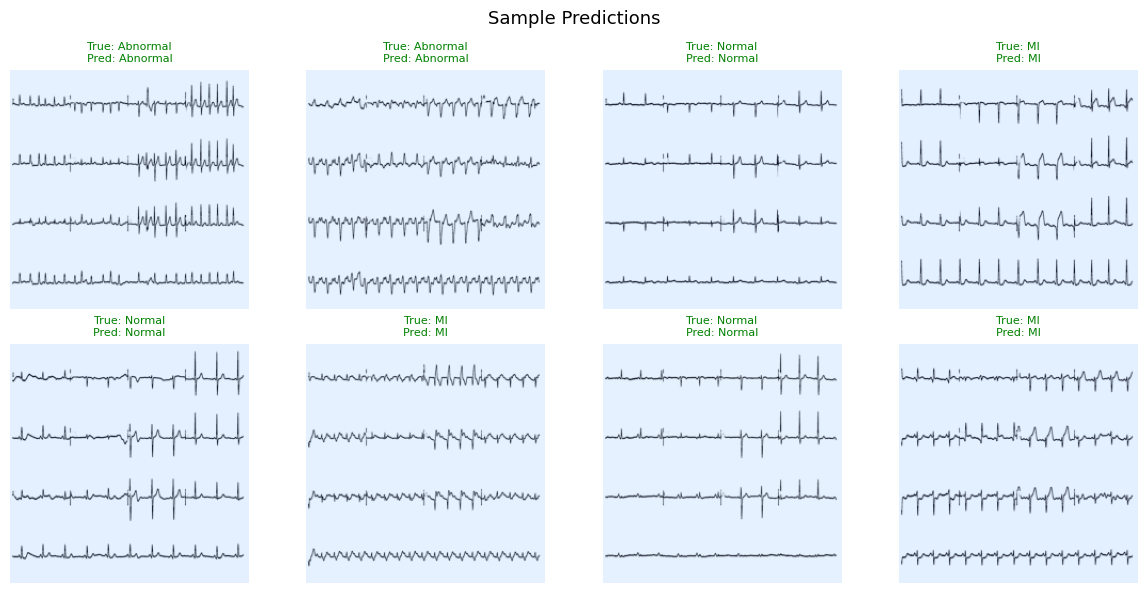

In [31]:
from utils.modeling import plot_sample_predictions

# Ganti model dan dataset sesuai hasil terbaik yang diperoleh
best_model   = model_s1_4c
best_dataset = dataset_s1_4c
best_classes = CLASS_NAMES_4

plot_sample_predictions(
    model=best_model,
    dataset=best_dataset,
    class_names=best_classes,
    device=DEVICE,
    num_samples=8
)